# Patient1_J32_41：读取矢状面图像

读取 `data_repos_Patient1_J32_41_sag.mat`，检查字段并显示其中的 `data_sag`。

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neuf_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat, whosmat

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "code_seg_3D").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the NeUF project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
MAT_PATH = PROJECT_ROOT / "code_seg_3D/Pre_traitement_echo_v2/Cropping/Patient1_J32_41/data_repos_Patient1_J32_41_sag.mat"
OUTPUT_DIR = PROJECT_ROOT / "notebooks/Patient1_J32_41_sag_check"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"MAT file: {MAT_PATH}")
print(f"exists: {MAT_PATH.exists()}")
print(f"size: {MAT_PATH.stat().st_size / 1024:.1f} KiB")

MAT file: /misc/raid/zchen/Code/NeUF/code_seg_3D/Pre_traitement_echo_v2/Cropping/Patient1_J32_41/data_repos_Patient1_J32_41_sag.mat
exists: True
size: 323.8 KiB


In [2]:
print("MAT fields:")
for name, shape, dtype in whosmat(MAT_PATH):
    print(f"  {name}: shape={shape}, dtype={dtype}")

mat = loadmat(MAT_PATH, variable_names=["data_sag"], simplify_cells=True)
data_sag = mat["data_sag"]

print(f"data_sag.shape = {data_sag.shape}")
print(f"data_sag.dtype = {data_sag.dtype}")
print(f"intensity range = [{data_sag.min()}, {data_sag.max()}]")
print(f"mean intensity = {data_sag.mean():.3f}")
print(f"non-zero pixels = {np.count_nonzero(data_sag):,} / {data_sag.size:,}")

MAT fields:
  data_sag: shape=(708, 944), dtype=uint8
data_sag.shape = (708, 944)
data_sag.dtype = uint8
intensity range = [0, 226]
mean intensity = 39.002
non-zero pixels = 489,154 / 668,352


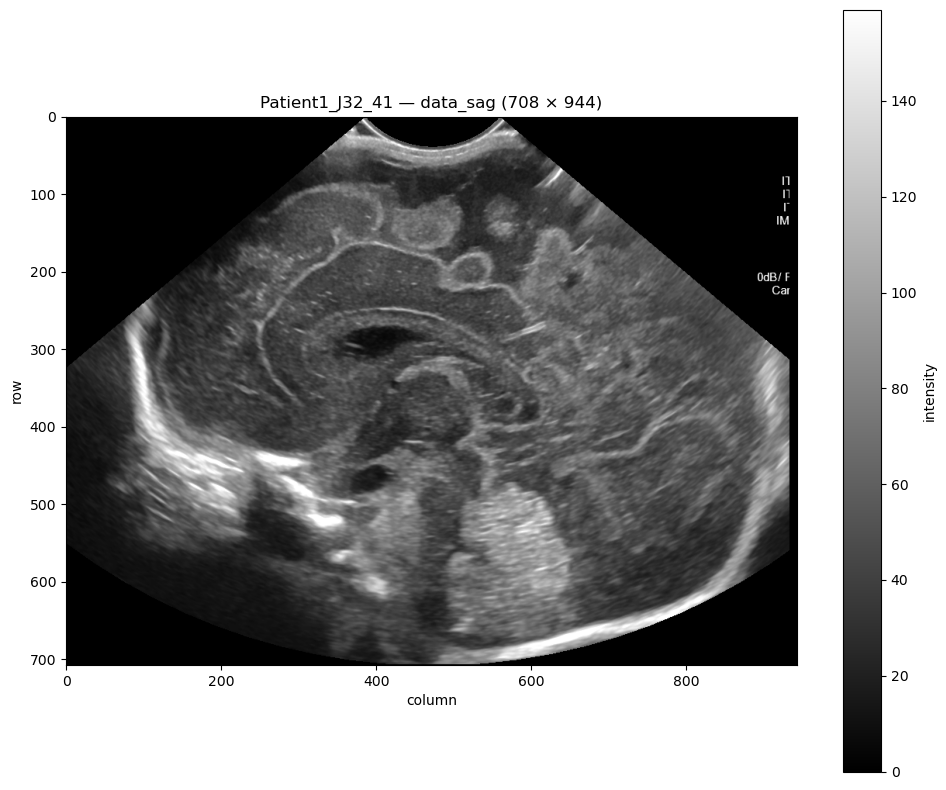

Saved preview: /misc/raid/zchen/Code/NeUF/notebooks/Patient1_J32_41_sag_check/data_sag_preview.png


In [3]:
nonzero = data_sag[data_sag > 0]
vmax = float(np.percentile(nonzero, 99.5)) if nonzero.size else 1.0

fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
image = ax.imshow(data_sag, cmap="gray", vmin=0, vmax=vmax)
ax.set_title("Patient1_J32_41 — data_sag (708 × 944)")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(image, ax=ax, label="intensity")
fig.tight_layout()
preview_path = OUTPUT_DIR / "data_sag_preview.png"
fig.savefig(preview_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved preview: {preview_path}")

## 结论

这个 MAT 文件只包含 `data_sag`：一张尺寸为 `708×944` 的 `uint8` 二维矢状方向图像，不是 3D 扫描体。